# ClinVision AI — RSNA Pneumonia Detection

## Notebook maître : de zéro à modèle + Grad-CAM + benchmark

Ce notebook contient **toute la partie Machine Learning** du projet. Il remplace les anciens scripts/notebooks multiples.

### Ce que nous allons construire

1. Vérifier l'environnement et sélectionner **CUDA / Apple Silicon Metal / CPU** automatiquement.
2. Localiser et auditer le dataset RSNA.
3. Construire une table patient-level sans fuite de données.
4. Créer un split **train / validation / test au niveau patient**.
5. Nettoyer et convertir les DICOM une seule fois dans un cache PNG.
6. Construire un pipeline `tf.data` rapide.
7. Entraîner DenseNet121 avec transfer learning.
8. Fine-tuner les dernières couches avec un petit learning rate.
9. Évaluer accuracy, ROC-AUC, PR-AUC, precision, recall, specificity et F1.
10. Chercher un seuil de décision sur validation et le figer avant le test.
11. Générer des courbes et matrices de confusion.
12. Générer un Grad-CAM.
13. Sauvegarder le modèle final utilisable par FastAPI et Streamlit.

> **Important :** 90% d'accuracy n'est pas garanti. Le code est volontairement optimisé pour améliorer l'accuracy brute, mais nous conserverons aussi les métriques médicalement pertinentes pour éviter une fausse impression de performance.

> **Nouveau flux dataset :** le notebook peut authentifier Kaggle, télécharger automatiquement le RSNA Pneumonia Detection Challenge, extraire les archives et alimenter directement le pipeline de preprocessing/training.


## 0. Architecture et choix techniques

Le cahier des charges fourni demande `TensorFlow/Keras + DenseNet121 + pydicom + FastAPI + Streamlit`.

### Pourquoi nous gardons TensorFlow/Keras

Le modèle doit suivre la spécification source. Pour NVIDIA, TensorFlow utilise CUDA. Pour Apple Silicon, TensorFlow peut être accéléré via l'écosystème `tensorflow-metal`; ce n'est pas l'API PyTorch `torch.device("mps")`. Le notebook ne dépend donc pas d'un backend PyTorch : il demande à TensorFlow quels GPUs sont visibles et utilise ce que le runtime expose.

### Pourquoi un cache DICOM

Le pipeline précédent décodait des DICOM pendant les epochs. Cela coûte cher parce que `pydicom` s'exécute côté Python/CPU. Nous faisons désormais :

```text
DICOM → preprocessing → PNG 320×320
                         ↑
                 une seule fois

PNG cache → tf.data → GPU/CPU
                  ↑
              chaque epoch
```

Cette architecture réduit fortement le coût CPU/I/O pendant l'entraînement.

In [1]:
# =========================
# 1. Imports et constantes
# =========================
# Nous importons toutes les bibliothèques une seule fois afin que le reste
# du notebook soit reproductible sans dépendre de modules Python externes.

from pathlib import Path
import os
import sys
import json
import time
import random
import warnings
import platform
import subprocess
import shutil
import zipfile

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import pydicom
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from pydicom.pixels import apply_modality_lut, apply_voi_lut

SEED = 42
IMAGE_SIZE = 320
BATCH_SIZE = 8
HEAD_EPOCHS = 10
FINETUNE_EPOCHS = 20
FINE_TUNE_LAYERS = 80
HEAD_LR = 3e-4
FINETUNE_LR = 5e-6
DROPOUT = 0.20
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.15
TEST_SIZE = 0.10
USE_CLASS_WEIGHTS = False  # False = accuracy-oriented profile.
CACHE_VERSION = f"v2_{IMAGE_SIZE}"

# -----------------------------------------------------------------------------
# Détection robuste de la racine du projet
# -----------------------------------------------------------------------------
# Colab peut ouvrir un notebook stocké dans /content/Clinvision-AI tout en gardant
# /content comme répertoire courant. Nous cherchons donc quelques emplacements
# plausibles avant de retomber sur Path.cwd().
cwd = Path.cwd()
root_candidates = [
    cwd,
    cwd / "Clinvision-AI",
    cwd / "clinvision-ai",
    cwd / "clinvision-ai-final",
    cwd.parent,
]
if Path("/content").exists():
    root_candidates.extend([
        Path("/content/Clinvision-AI"),
        Path("/content/clinvision-ai"),
        Path("/content/clinvision-ai-final"),
    ])

ROOT = cwd
for candidate in root_candidates:
    if (candidate / "data").exists() or (candidate / "models").exists() or (candidate / "ClinVision_AI_RSNA.ipynb").exists():
        ROOT = candidate
        break

DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
TRAIN_DICOM_DIR = RAW_DIR / "stage_2_train_images"
META_DIR = DATA_DIR / "metadata"
CACHE_DIR = DATA_DIR / "cache_320"
MODELS_DIR = ROOT / "models"
ARTIFACTS_DIR = ROOT / "artifacts"

for directory in [DATA_DIR, RAW_DIR, META_DIR, CACHE_DIR, MODELS_DIR, ARTIFACTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Project root:", ROOT)
print("TensorFlow:", tf.__version__)

Python: 3.11.16 (main, Sep 21 2026, 19:20:22) [Clang 21.0.0 (clang-2100.3.34.2)]
Platform: macOS-26.6.2-arm64-arm-64bit
Project root: /Users/mac/Downloads/clinvision-ai-final
TensorFlow: 2.18.1


In [2]:
# ==============================================
# 2. Reproductibilité et sélection du matériel
# ==============================================
# On fixe les graines pour réduire la variance expérimentale. La reproductibilité
# parfaite n'est pas garantie sur GPU, mais ce bloc rend les expériences beaucoup
# plus comparables entre deux exécutions.

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Demande à TensorFlow quels appareils physiques sont visibles.
physical_gpus = tf.config.list_physical_devices("GPU")
physical_cpus = tf.config.list_physical_devices("CPU")

for gpu in physical_gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print("CPU devices:", physical_cpus)
print("GPU devices:", physical_gpus)

if physical_gpus:
    DEVICE_MODE = "GPU"
    print("✅ TensorFlow utilisera le GPU visible (CUDA sous Linux/NVIDIA ou Metal sous macOS si le plugin Apple est installé).")
elif platform.system() == "Darwin" and platform.machine().lower() in {"arm64", "aarch64"}:
    DEVICE_MODE = "APPLE-SILICON-CPU-FALLBACK"
    print("⚠️ Apple Silicon détecté, mais TensorFlow ne voit aucun GPU. Vérifie tensorflow-metal.")
else:
    DEVICE_MODE = "CPU"
    print("ℹ️ Aucun GPU TensorFlow visible : entraînement CPU.")

CPU devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ TensorFlow utilisera le GPU visible (CUDA sous Linux/NVIDIA ou Metal sous macOS si le plugin Apple est installé).


### 2.1 Vérification NVIDIA / CUDA (optionnelle)

Si le notebook tourne sur Linux/WSL2 et qu'un GPU NVIDIA est attendu, `nvidia-smi` doit également être disponible. Si cette commande échoue mais que TensorFlow voit un GPU, ce n'est pas forcément bloquant ; inversement, si `nvidia-smi` fonctionne mais que TensorFlow ne voit aucun GPU, l'environnement Python CUDA doit être corrigé.

In [3]:
# Cette cellule ne fait qu'un diagnostic : elle ne modifie rien.
try:
    result = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"], capture_output=True, text=True)
    if result.returncode == 0:
        print("NVIDIA-SMI:")
        print(result.stdout.strip())
    else:
        print("nvidia-smi non disponible ou aucun GPU NVIDIA visible.")
except FileNotFoundError:
    print("nvidia-smi non installé — normal sur Mac/CPU.")

nvidia-smi non installé — normal sur Mac/CPU.


## 3. Installation des dépendances

### Colab / Linux CUDA

```bash
!pip install -q "tensorflow[and-cuda]==2.18.1" pandas scikit-learn matplotlib seaborn opencv-python-headless pydicom pillow scipy requests python-dotenv
```

### Mac Apple Silicon

```bash
%pip install -q -r requirements.txt
%pip install -q tensorflow-metal==1.2.0
```

### CPU

```bash
%pip install -q -r requirements.txt
```

Après une installation TensorFlow/Metal, un redémarrage du kernel peut être nécessaire.

## 4. Dataset RSNA — téléchargement automatique depuis Kaggle

Le notebook peut maintenant **télécharger automatiquement le dataset officiel RSNA Pneumonia Detection Challenge**, puis l'extraire, le vérifier et l'utiliser directement pour la suite du pipeline.

Le concours doit d'abord être rejoint et ses règles acceptées sur Kaggle. Ensuite, le notebook utilise le CLI officiel : `kaggle competitions download rsna-pneumonia-detection-challenge`. Le CLI Kaggle actuel accepte notamment `-p/--path` pour le dossier de destination et `--unzip` pour extraire l'archive. Nous utilisons ici un téléchargement sans `--unzip`, puis une extraction Python récursive afin de gérer proprement les archives imbriquées du dataset RSNA. citeturn885699search0turn885699search5

### Fichiers attendus

```text
stage_2_train_images/
stage_2_train_labels.csv
stage_2_detailed_class_info.csv
stage_2_sample_submission.csv
```

### Authentification Kaggle

Le notebook recherche automatiquement les identifiants dans cet ordre :

1. variables d'environnement `KAGGLE_USERNAME` et `KAGGLE_KEY` ;
2. `~/.kaggle/kaggle.json` ;
3. Google Colab : upload interactif de `kaggle.json`.

**Ne mets jamais `kaggle.json`, `KAGGLE_KEY` ou un token dans Git.** Le `.gitignore` du projet les exclut.

### Espace disque

Le dataset RSNA est volumineux. Prévois suffisamment d'espace avant d'exécuter le téléchargement. Le cahier des charges recommande déjà un volume de stockage conséquent ou l'utilisation d'un sous-ensemble préparé. fileciteturn0file0L58-L64

In [4]:
# =========================================================
# 4.1 Préparer l'accès Kaggle
# =========================================================
# Cette cellule ne télécharge pas encore les DICOM.
# Elle installe le client Kaggle si nécessaire et prépare les credentials.
#
# Pourquoi deux étapes ?
# ---------------------
# 1) Séparer l'authentification du téléchargement rend le notebook plus facile
#    à reprendre en cas d'interruption réseau.
# 2) Les secrets restent hors du code source.
# 3) Sur Colab, l'utilisateur peut simplement uploader kaggle.json.

import json as _json
import os as _os
from pathlib import Path as _Path
import shutil as _shutil
import subprocess as _subprocess
import sys as _sys

KAGGLE_COMPETITION = "rsna-pneumonia-detection-challenge"
KAGGLE_CONFIG_DIR = _Path.home() / ".kaggle"
KAGGLE_CONFIG_PATH = KAGGLE_CONFIG_DIR / "kaggle.json"


def _run_quiet(cmd):
    """Retourne True si une commande shell s'exécute correctement."""
    result = _subprocess.run(cmd, stdout=_subprocess.PIPE, stderr=_subprocess.PIPE, text=True)
    return result.returncode == 0, result.stdout, result.stderr


# Étape 1 — Installer le client officiel Kaggle s'il n'est pas déjà disponible.
if _shutil.which("kaggle") is None:
    print("📦 Installation du client Kaggle...")
    _subprocess.run([_sys.executable, "-m", "pip", "install", "-q", "kaggle"], check=True)
else:
    print("✅ Client Kaggle déjà disponible.")


# Étape 2 — Chercher les credentials via variables d'environnement.
username = _os.environ.get("KAGGLE_USERNAME")
key = _os.environ.get("KAGGLE_KEY")

if username and key:
    print("✅ KAGGLE_USERNAME / KAGGLE_KEY détectés dans l'environnement.")
else:
    # Étape 3 — Chercher le fichier standard ~/.kaggle/kaggle.json.
    if KAGGLE_CONFIG_PATH.exists():
        print(f"✅ Credentials Kaggle trouvés : {KAGGLE_CONFIG_PATH}")
    else:
        # Étape 4 — Si nous sommes dans Google Colab, proposer l'upload sécurisé du fichier.
        try:
            from google.colab import files as _colab_files
            print("📤 Upload requis : sélectionne ton fichier kaggle.json téléchargé depuis Kaggle.")
            uploaded = _colab_files.upload()
            if "kaggle.json" not in uploaded:
                raise FileNotFoundError("Le fichier uploadé doit s'appeler kaggle.json")
            KAGGLE_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
            (KAGGLE_CONFIG_DIR / "kaggle.json").write_bytes(uploaded["kaggle.json"])
            print(f"✅ kaggle.json copié vers {KAGGLE_CONFIG_PATH}")
        except ImportError:
            raise RuntimeError(
                "Credentials Kaggle introuvables. Définis KAGGLE_USERNAME/KAGGLE_KEY "
                "ou place kaggle.json dans ~/.kaggle/kaggle.json."
            )


# Étape 5 — Vérifier/normaliser les permissions du fichier de credentials.
if KAGGLE_CONFIG_PATH.exists():
    try:
        KAGGLE_CONFIG_PATH.chmod(0o600)
    except Exception:
        # Sur certains systèmes, chmod peut être limité ; le client Kaggle peut
        # néanmoins fonctionner si le système de fichiers est déjà sécurisé.
        pass

# Étape 6 — Test minimal de l'authentification sans télécharger le dataset.
ok, out, err = _run_quiet(["kaggle", "competitions", "files", KAGGLE_COMPETITION, "-q"])
if not ok:
    print(err[-2000:])
    raise RuntimeError(
        "Authentification/accès Kaggle impossible. Vérifie que tu as rejoint la "
        "compétition RSNA et accepté ses règles, puis vérifie kaggle.json."
    )

print("✅ Accès Kaggle validé.")
print("Competition:", KAGGLE_COMPETITION)

✅ Client Kaggle déjà disponible.
✅ Credentials Kaggle trouvés : /Users/mac/.kaggle/kaggle.json
✅ Accès Kaggle validé.
Competition: rsna-pneumonia-detection-challenge


In [5]:
# =========================================================
# 4.2 Télécharger + extraire + vérifier le dataset RSNA
# =========================================================
# Cette cellule est idempotente : si les fichiers principaux sont déjà présents,
# elle ne retélécharge pas inutilement plusieurs gigaoctets.
#
# Flux :
# Kaggle → archive ZIP → extraction récursive → data/raw/
#       → vérification des labels + images → pipeline ML

import os as _os
import zipfile as _zipfile
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

KAGGLE_DOWNLOAD_DIR = RAW_DIR
KAGGLE_DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_LABELS = KAGGLE_DOWNLOAD_DIR / "stage_2_train_labels.csv"
EXPECTED_DETAILED = KAGGLE_DOWNLOAD_DIR / "stage_2_detailed_class_info.csv"
EXPECTED_SAMPLE = KAGGLE_DOWNLOAD_DIR / "stage_2_sample_submission.csv"
EXPECTED_IMAGES = KAGGLE_DOWNLOAD_DIR / "stage_2_train_images"


def _dataset_ready():
    """Vérifie les éléments indispensables avant de relancer un téléchargement."""
    return EXPECTED_LABELS.exists() and EXPECTED_IMAGES.exists() and any(EXPECTED_IMAGES.glob("*.dcm"))


def _extract_all_zips(root_dir: _Path):
    """Extrait récursivement toutes les archives ZIP trouvées dans root_dir.

    Le dataset Kaggle peut contenir plusieurs archives. Une extraction récursive
    permet de traiter aussi les ZIP imbriqués sans supposer leur nom exact.
    """
    extracted_any = False
    processed = set()

    while True:
        archives = [p for p in root_dir.rglob("*.zip") if p not in processed]
        if not archives:
            break

        progress = False
        for archive in archives:
            processed.add(archive)
            target = archive.parent
            marker = target / f".{archive.stem}.extracted"

            if marker.exists():
                continue

            print(f"📦 Extraction : {archive.name}")
            with _zipfile.ZipFile(archive, "r") as zf:
                zf.extractall(target)

            marker.write_text("ok", encoding="utf-8")
            extracted_any = True
            progress = True

        if not progress:
            break

    return extracted_any


# Étape 1 — Si le dataset est déjà prêt, on réutilise directement les fichiers.
if _dataset_ready():
    print("✅ Dataset RSNA déjà présent : téléchargement ignoré.")
else:
    # Étape 2 — Nettoyer uniquement les anciens marqueurs ZIP incomplets si besoin.
    print("⬇️ Téléchargement du dataset RSNA depuis Kaggle...")
    command = [
        "kaggle",
        "competitions",
        "download",
        KAGGLE_COMPETITION,
        "--path",
        str(KAGGLE_DOWNLOAD_DIR),
    ]

    result = _subprocess.run(command)
    if result.returncode != 0:
        raise RuntimeError(
            "Le téléchargement Kaggle a échoué. Vérifie la connexion Internet, "
            "l'authentification Kaggle et l'acceptation des règles du concours."
        )

    # Étape 3 — Extraction récursive de toutes les archives récupérées.
    _extract_all_zips(KAGGLE_DOWNLOAD_DIR)


# Étape 4 — Recherche récursive si Kaggle a créé un sous-dossier intermédiaire.
label_matches = list(KAGGLE_DOWNLOAD_DIR.rglob("stage_2_train_labels.csv"))
image_matches = list(KAGGLE_DOWNLOAD_DIR.rglob("stage_2_train_images"))
detailed_matches = list(KAGGLE_DOWNLOAD_DIR.rglob("stage_2_detailed_class_info.csv"))
sample_matches = list(KAGGLE_DOWNLOAD_DIR.rglob("stage_2_sample_submission.csv"))

if not label_matches or not image_matches:
    raise FileNotFoundError(
        "Le dataset a été téléchargé/extrait, mais stage_2_train_labels.csv ou "
        "stage_2_train_images/ est introuvable. Inspecte data/raw/ avant de relancer."
    )

# Étape 5 — Définir les chemins globaux utilisés par toutes les cellules suivantes.
LABELS_CSV = label_matches[0]
DETAILED_CSV = detailed_matches[0] if detailed_matches else None
SAMPLE_CSV = sample_matches[0] if sample_matches else None
TRAIN_DICOM_DIR = image_matches[0]

# Étape 6 — Compter les DICOM pour confirmer que l'extraction contient réellement les images.
dicom_count = len(list(TRAIN_DICOM_DIR.glob("*.dcm")))
if dicom_count == 0:
    raise RuntimeError(f"Le dossier existe mais aucun DICOM n'a été trouvé : {TRAIN_DICOM_DIR}")

print("\n✅ DATASET RSNA PRÊT")
print("Labels:", LABELS_CSV)
print("Detailed class info:", DETAILED_CSV)
print("Sample submission:", SAMPLE_CSV)
print("DICOM directory:", TRAIN_DICOM_DIR)
print("Nombre de DICOM détectés:", f"{dicom_count:,}")

⬇️ Téléchargement du dataset RSNA depuis Kaggle...


100%|██████████| 3.66G/3.66G [01:20<00:00, 49.0MB/s]



📦 Extraction : rsna-pneumonia-detection-challenge.zip

✅ DATASET RSNA PRÊT
Labels: /Users/mac/Downloads/clinvision-ai-final/data/raw/stage_2_train_labels.csv
Detailed class info: /Users/mac/Downloads/clinvision-ai-final/data/raw/stage_2_detailed_class_info.csv
Sample submission: /Users/mac/Downloads/clinvision-ai-final/data/raw/stage_2_sample_submission.csv
DICOM directory: /Users/mac/Downloads/clinvision-ai-final/data/raw/stage_2_train_images
Nombre de DICOM détectés: 26,684


In [6]:

# ==============================================
# 4.3 Découverte / résolution finale des chemins
# ==============================================
# Si la cellule de téléchargement a déjà défini les chemins, nous les réutilisons.
# Sinon, on effectue une recherche récursive afin que le notebook reste compatible
# avec un dataset téléchargé/extrait manuellement.

label_candidates = list(RAW_DIR.rglob("stage_2_train_labels.csv"))
detailed_candidates = list(RAW_DIR.rglob("stage_2_detailed_class_info.csv"))
image_candidates = list(RAW_DIR.rglob("stage_2_train_images"))

if not label_candidates or not image_candidates:
    raise FileNotFoundError(
        "Dataset RSNA introuvable. Place stage_2_train_labels.csv et stage_2_train_images/ sous data/raw/ puis relance."
    )

LABELS_CSV = label_candidates[0]
DETAILED_CSV = detailed_candidates[0] if detailed_candidates else None
TRAIN_DICOM_DIR = image_candidates[0]

print("Labels:", LABELS_CSV)
print("Detailed class info:", DETAILED_CSV)
print("DICOM directory:", TRAIN_DICOM_DIR)


Labels: /Users/mac/Downloads/clinvision-ai-final/data/raw/stage_2_train_labels.csv
Detailed class info: /Users/mac/Downloads/clinvision-ai-final/data/raw/stage_2_detailed_class_info.csv
DICOM directory: /Users/mac/Downloads/clinvision-ai-final/data/raw/stage_2_train_images


In [7]:
# =========================
# 4.4 Lecture des labels
# =========================
labels = pd.read_csv(LABELS_CSV)
required_columns = {"patientId", "Target"}
missing = required_columns - set(labels.columns)
if missing:
    raise ValueError(f"Colonnes manquantes dans le CSV RSNA: {missing}")

labels["Target"] = labels["Target"].astype(int)
labels["patientId"] = labels["patientId"].astype(str)

print("Rows:", len(labels))
print("Unique patients:", labels["patientId"].nunique())
print("Missing values:\n", labels.isna().sum())
print("Raw targets:\n", labels["Target"].value_counts(dropna=False).sort_index())

Rows: 30227
Unique patients: 26684
Missing values:
 patientId        0
x            20672
y            20672
width        20672
height       20672
Target           0
dtype: int64
Raw targets:
 Target
0    20672
1     9555
Name: count, dtype: int64


Unique patients: 26684
Positive patients: 6012
Negative patients: 20672
Patients with multiple label rows: 3398
Missing DICOM files: 0


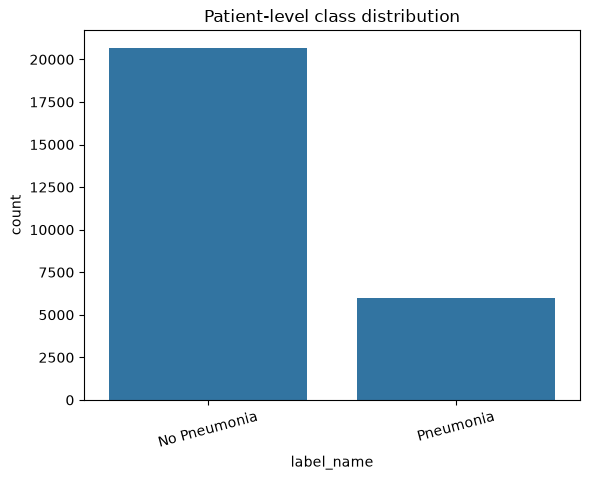

In [8]:
# =============================================
# 4.5 Agrégation image/patient et bounding boxes
# =============================================
# Le CSV peut contenir plusieurs lignes pour un même patient lorsqu'il existe
# plusieurs bounding boxes. Pour la classification, un patient est positif si
# au moins une ligne Target == 1.

patient_table = (
    labels.groupby("patientId", as_index=False)
    .agg(label=("Target", "max"), rows=("Target", "size"))
)
patient_table["label"] = patient_table["label"].astype(int)
patient_table["dicom_path"] = patient_table["patientId"].map(
    lambda pid: str(TRAIN_DICOM_DIR / f"{pid}.dcm")
)
patient_table["exists"] = patient_table["dicom_path"].map(lambda p: Path(p).exists())

print("Unique patients:", len(patient_table))
print("Positive patients:", int(patient_table["label"].sum()))
print("Negative patients:", int((patient_table["label"] == 0).sum()))
print("Patients with multiple label rows:", int((patient_table["rows"] > 1).sum()))
print("Missing DICOM files:", int((~patient_table["exists"]).sum()))

# Visualisation du déséquilibre.
patient_table["label_name"] = patient_table["label"].map({0: "No Pneumonia", 1: "Pneumonia"})
sns.countplot(data=patient_table, x="label_name")
plt.title("Patient-level class distribution")
plt.xticks(rotation=15)
plt.show()

## 5. Patient-level split — règle critique

Nous ne faisons **jamais** `train_test_split(labels)` directement sur les lignes du CSV car un même patient peut apparaître plusieurs fois à cause des bounding boxes.

Le split est effectué sur `patient_table`, puis les patients sélectionnés sont reconvertis en images. C'est la protection principale contre le data leakage dans ce projet.

In [9]:
# =================================================
# 5.1 Train / validation / test par patient
# =================================================
# Première séparation : test final.
train_val, test_df = train_test_split(
    patient_table,
    test_size=TEST_SIZE,
    stratify=patient_table["label"],
    random_state=SEED,
)

# Deuxième séparation : validation à l'intérieur du reste.
val_fraction_relative = VAL_SIZE / (1.0 - TEST_SIZE)
train_df, val_df = train_test_split(
    train_val,
    test_size=val_fraction_relative,
    stratify=train_val["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_patients = set(train_df["patientId"])
val_patients = set(val_df["patientId"])
test_patients = set(test_df["patientId"])

assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

print("Train patients:", len(train_df), train_df["label"].mean())
print("Validation patients:", len(val_df), val_df["label"].mean())
print("Test patients:", len(test_df), test_df["label"].mean())

train_df.to_csv(META_DIR / "train_patients.csv", index=False)
val_df.to_csv(META_DIR / "val_patients.csv", index=False)
test_df.to_csv(META_DIR / "test_patients.csv", index=False)

Train patients: 20012 0.22531481111333201
Validation patients: 4003 0.22533100174868848
Test patients: 2669 0.22517796927688272


## 6. DICOM preprocessing robuste

Le cahier des charges précise :

```text
DICOM → pixel_array → normalisation → resize → RGB 3 canaux → tensor
```

Nous ajoutons trois protections :

- application de la LUT de modalité quand présente ;
- application VOI LUT quand disponible ;
- inversion `MONOCHROME1` ;
- normalisation robuste par percentiles 1–99.

Ensuite, nous créons un **cache PNG 320×320**. Les erreurs de lecture sont isolées dans `artifacts/preprocess_errors.csv` au lieu de stopper toute la préparation.

In [10]:
# ==========================================================
# 6.1 Fonction de lecture et normalisation d'un DICOM
# ==========================================================
def dicom_to_uint8(path: str | Path) -> np.ndarray:
    """Read a DICOM and return a robustly normalized uint8 grayscale image."""
    ds = pydicom.dcmread(str(path), force=False)
    arr = ds.pixel_array.astype(np.float32)

    # Modality LUT convertit les valeurs de pixels vers l'échelle physique
    # lorsque le DICOM fournit RescaleSlope/RescaleIntercept ou une LUT équivalente.
    try:
        arr = apply_modality_lut(arr, ds).astype(np.float32)
    except Exception:
        pass

    # VOI LUT peut représenter la fenêtre/présentation voulue par le scanner.
    try:
        arr = apply_voi_lut(arr, ds).astype(np.float32)
    except Exception:
        pass

    # MONOCHROME1 signifie généralement que les faibles valeurs sont affichées
    # comme blanc : nous remettons la polarité dans le sens conventionnel.
    if getattr(ds, "PhotometricInterpretation", "MONOCHROME2") == "MONOCHROME1":
        arr = arr.max() - arr

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    low, high = np.percentile(arr, [1.0, 99.0])

    if not np.isfinite(low) or not np.isfinite(high) or high <= low:
        low, high = float(arr.min()), float(arr.max())

    if high <= low:
        return np.zeros(arr.shape, dtype=np.uint8)

    arr = np.clip((arr - low) / (high - low), 0.0, 1.0)
    return (arr * 255.0).astype(np.uint8)


def cache_one(row: pd.Series, split_name: str) -> dict:
    """Create one resized PNG cache entry and return metadata/status."""
    source = Path(row["dicom_path"])
    relative = Path(split_name) / f"{row['patientId']}.png"
    destination = CACHE_DIR / relative
    destination.parent.mkdir(parents=True, exist_ok=True)

    try:
        gray = dicom_to_uint8(source)
        if gray.ndim != 2 or min(gray.shape) < 32:
            raise ValueError(f"invalid/too-small image shape: {gray.shape}")

        resized = cv2.resize(gray, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
        # Le PNG préserve exactement les valeurs 8-bit calculées par notre
        # preprocessing et est décodable directement par tf.io.decode_png.
        ok = cv2.imwrite(str(destination), resized)
        if not ok:
            raise IOError("OpenCV failed to write PNG cache")

        return {
            "patientId": row["patientId"],
            "label": int(row["label"]),
            "cache_path": str(destination),
            "status": "ok",
            "error": "",
        }
    except Exception as exc:
        return {
            "patientId": row["patientId"],
            "label": int(row["label"]),
            "cache_path": str(destination),
            "status": "error",
            "error": repr(exc),
        }

In [11]:
# ==============================================
# 6.2 Construction du cache pour les 3 splits
# ==============================================
# Le cache peut prendre plusieurs minutes la première fois. Les fichiers
# existants et valides sont réutilisés afin que relancer la cellule soit sûr.

cache_frames = {}
preprocess_errors = []

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    records = []
    for row in split_df.itertuples(index=False):
        pseudo = pd.Series({"patientId": row.patientId, "label": row.label, "dicom_path": row.dicom_path})
        expected = CACHE_DIR / split_name / f"{row.patientId}.png"
        if expected.exists() and expected.stat().st_size > 0:
            records.append({
                "patientId": row.patientId,
                "label": int(row.label),
                "cache_path": str(expected),
                "status": "cached",
                "error": "",
            })
            continue
        result = cache_one(pseudo, split_name)
        records.append(result)
        if result["status"] == "error":
            preprocess_errors.append(result)

    frame = pd.DataFrame(records)
    frame = frame[frame["status"].isin(["ok", "cached"])].reset_index(drop=True)
    frame.to_csv(META_DIR / f"{split_name}_cache.csv", index=False)
    cache_frames[split_name] = frame
    print(split_name, "valid cache files:", len(frame), "positive:", int(frame["label"].sum()))

pd.DataFrame(preprocess_errors).to_csv(ARTIFACTS_DIR / "preprocess_errors.csv", index=False)
print("Preprocessing errors:", len(preprocess_errors))

train valid cache files: 20012 positive: 4509
val valid cache files: 4003 positive: 902
test valid cache files: 2669 positive: 601
Preprocessing errors: 0


## 7. Visual quality control

Avant d'entraîner, nous regardons quelques positifs et négatifs à partir du cache. Cette étape est indispensable : un modèle ne peut pas corriger un pipeline qui inverse les intensités, mélange les labels ou charge de mauvaises images.

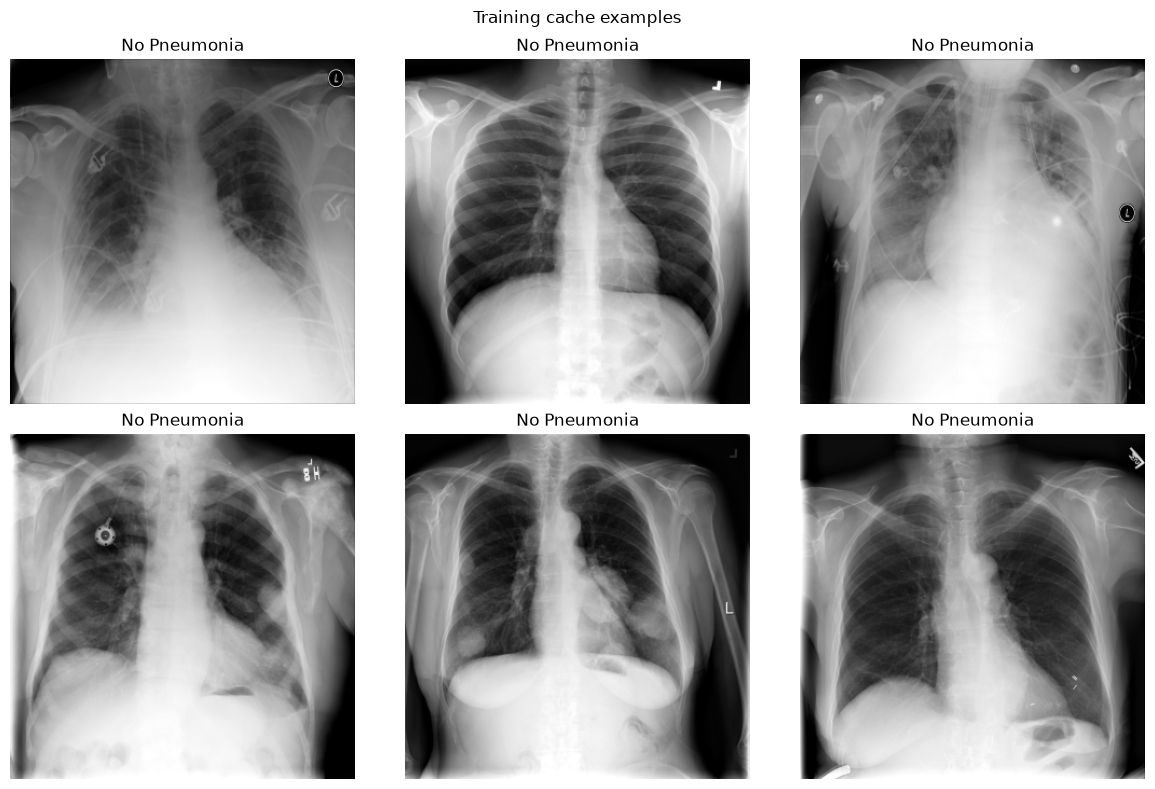

In [18]:
# =================================
# 7.1 Afficher quelques exemples
# =================================
def show_examples(frame: pd.DataFrame, title: str, n: int = 6):
    sample = frame.sample(min(n, len(frame)), random_state=SEED)
    cols = 3
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, sample.iterrows()):
        image = cv2.imread(row["cache_path"], cv2.IMREAD_GRAYSCALE)
        ax.imshow(image, cmap="gray")
        ax.set_title(f"{'Pneumonia' if row['label'] else 'No Pneumonia'}")
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_examples(cache_frames["train"], "Training cache examples")

## 8. `tf.data` pipeline rapide

Le point essentiel est maintenant que le GPU ne demande **jamais** à `pydicom` de décoder un DICOM pendant `model.fit()`.

```text
PNG cache
   ↓
TF decode
   ↓
resize / RGB
   ↓
augmentation (train only)
   ↓
DenseNet preprocess_input
   ↓
GPU / CPU
```

In [13]:
# ===========================================
# 8.1 Pipeline tf.data
# ===========================================
AUTOTUNE = tf.data.AUTOTUNE

# Augmentations modérées : elles doivent créer de la robustesse, pas fabriquer
# une radiographie anatomiquement improbable.
train_augment = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02, fill_mode="reflect"),
    tf.keras.layers.RandomTranslation(0.02, 0.02, fill_mode="reflect"),
    tf.keras.layers.RandomZoom(height_factor=(-0.08, 0.08), width_factor=(-0.08, 0.08), fill_mode="reflect"),
    tf.keras.layers.RandomContrast(0.08),
], name="train_augmentation")


def make_dataset(frame: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = frame["cache_path"].astype(str).values
    labels_array = frame["label"].astype(np.float32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_array))

    if training:
        ds = ds.shuffle(min(len(frame), 8192), seed=SEED, reshuffle_each_iteration=True)

    def load_png(path, label):
        image_bytes = tf.io.read_file(path)
        image = tf.io.decode_png(image_bytes, channels=1)
        image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE], method="bilinear")
        image = tf.cast(image, tf.float32)
        image = tf.image.grayscale_to_rgb(image)
        if training:
            # Les couches d'augmentation sont marquées training=True afin de
            # rester complètement désactivées pour validation/test.
            image = train_augment(image, training=True)
        # IMPORTANT : le modèle contient lui-même preprocess_input.
        # Nous envoyons donc ici des pixels 0–255 et ne prétraitons qu'une fois.
        return image, label

    ds = ds.map(load_png, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(cache_frames["train"], training=True)
val_ds = make_dataset(cache_frames["val"], training=False)
test_ds = make_dataset(cache_frames["test"], training=False)

print("Datasets created.")

2026-09-26 01:22:39.331587: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-26 01:22:39.331900: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-26 01:22:39.331921: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1790382159.332297 19291062 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1790382159.332652 19291062 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Datasets created.


## 9. Modèle DenseNet121

Architecture fidèle au plan source avec quelques améliorations de stabilité :

```text
Input 320×320×3
      ↓
DenseNet121 ImageNet (frozen puis fine-tuned)
      ↓
GlobalAveragePooling2D
      ↓
BatchNormalization
      ↓
Dropout(0.20)
      ↓
Dense(1, sigmoid)
```

### Pourquoi ne pas utiliser `class_weight="balanced"` par défaut ?

Ton ancien entraînement obtenait environ 0.71 de validation recall mais seulement ~0.52 de validation precision. Pour l'objectif **accuracy**, les poids de classe équilibrés ne sont pas neutres : ils donnent artificiellement plus de coût aux erreurs sur la classe minoritaire et peuvent donc déplacer le modèle vers plus de prédictions positives. Nous désactivons donc cette option dans le profil accuracy.

In [14]:
# ===================================
# 9.1 Construction du modèle
# ===================================
def build_model():
    inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="xray")

    # DenseNet121 est chargé avec les poids ImageNet comme demandé par le plan.
    # Le preprocessing DenseNet est placé dans le modèle pour garantir que le
    # même contrat d'entrée est respecté pendant le serving FastAPI.
    x = tf.keras.applications.densenet.preprocess_input(inputs)

    backbone = tf.keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        name="densenet121",
    )
    backbone.trainable = False

    x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pool")(backbone.output)
    x = tf.keras.layers.BatchNormalization(name="head_batch_norm")(x)
    x = tf.keras.layers.Dropout(DROPOUT, name="head_dropout")(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", dtype="float32", name="pneumonia_probability")(x)

    return tf.keras.Model(inputs, outputs, name="clinvision_pneumonia")

model = build_model()
model.summary()

Model: "clinvision_pneumonia"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xray (InputLayer)   │ (None, 320, 320,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 320, 320,  │          0 │ xray[0][0]        │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 320, 320,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 320, 320,  │          0 │ add[0][0]         │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 326, 326,  │          0 │ true_divide_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 160, 160,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 160, 160,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 160, 160,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 162, 162,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 80, 80,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 80, 80,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 80, 80,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 80, 80,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 80, 80,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 80, 80,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 80, 80,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 80, 80,    │          0 │ pool1[0][0],    

 Total params: 7,042,625 (26.87 MB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [15]:
# ===========================================
# 9.2 Optimizer, loss et métriques
# ===========================================
# AdamW ajoute une légère régularisation des poids sans nécessiter une loss
# exotique. L'accuracy est calculée au seuil 0.5 pour rester lisible.
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
    clipnorm=1.0,
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.01),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
        tf.keras.metrics.AUC(name="auc", curve="ROC"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        tf.keras.metrics.Precision(name="precision", thresholds=0.5),
        tf.keras.metrics.Recall(name="recall", thresholds=0.5),
    ],
)

print("Trainable parameters initially:", sum(np.prod(v.shape) for v in model.trainable_weights))

Trainable parameters initially: 3073


In [16]:
# ========================================
# 9.3 Class weights — option diagnostic
# ========================================
# Cette cellule calcule les poids, mais ne les applique que si
# USE_CLASS_WEIGHTS=True. Pour l'objectif accuracy, laisse False.
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=cache_frames["train"]["label"].values,
)
CLASS_WEIGHTS = {int(c): float(w) for c, w in zip(classes, weights)}
print("Computed class weights:", CLASS_WEIGHTS)
print("Applied:", USE_CLASS_WEIGHTS)

Computed class weights: {0: 0.645423466425853, 1: 2.2191173209137283}
Applied: False


## 10. Callbacks

Nous sauvegardons **deux checkpoints** :

- celui qui maximise `val_accuracy` — ton objectif principal ;
- celui qui maximise `val_auc` — contrôle qualité indépendant.

Ainsi, si l'accuracy monte au détriment de l'AUC, nous le verrons immédiatement.

In [17]:
# ===================================
# 10.1 Callbacks Stage A
# ===================================
def make_callbacks(stage_name: str):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            MODELS_DIR / f"best_{stage_name}_val_accuracy.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            MODELS_DIR / f"best_{stage_name}_val_auc.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy",
            mode="max",
            factor=0.25,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(ARTIFACTS_DIR / f"training_{stage_name}.csv", append=False),
    ]

class_weight_arg = CLASS_WEIGHTS if USE_CLASS_WEIGHTS else None

## 11. Stage A — Transfer learning

Le backbone DenseNet121 est gelé. Nous entraînons d'abord la tête de classification. Cette étape permet à la nouvelle couche sigmoid de s'aligner avec les représentations déjà apprises avant d'autoriser des modifications du backbone.

In [19]:
# =====================================
# 11.1 Entraînement du classifier head
# =====================================
start_time = time.time()

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weight_arg,
    callbacks=make_callbacks("head"),
    verbose=1,
)

print(f"Stage A duration: {(time.time() - start_time) / 60:.1f} min")

Epoch 1/10


2026-09-26 01:25:01.445052: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2502/2502 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.7810 - auc: 0.7569 - loss: 0.4770 - pr_auc: 0.4634 - precision: 0.5220 - recall: 0.3342
Epoch 1: val_accuracy improved from None to 0.80789, saving model to /Users/mac/Downloads/clinvision-ai-final/models/best_head_val_accuracy.keras

Epoch 1: finished saving model to /Users/mac/Downloads/clinvision-ai-final/models/best_head_val_accuracy.keras

Epoch 1: val_auc improved from None to 0.81510, saving model to /Users/mac/Downloads/clinvision-ai-final/models/best_head_val_auc.keras

Epoch 1: finished saving model to /Users/mac/Downloads/clinvision-ai-final/models/best_head_val_auc.keras
2502/2502 ━━━━━━━━━━━━━━━━━━━━ 598s 235ms/step - accuracy: 0.7810 - auc: 0.7569 - loss: 0.4770 - pr_auc: 0.4634 - precision: 0.5220 - recall: 0.3342 - val_accuracy: 0.8079 - val_auc: 0.8151 - val_loss: 0.4363 - val_pr_auc: 0.5426 - val_precision: 0.6064 - val_recall: 0.4202 - learning_rate: 3.0000e-04
Epoch 2/10
2502/2502 ━━━━━━━━━━━━━━━━━━━━ 0s 183

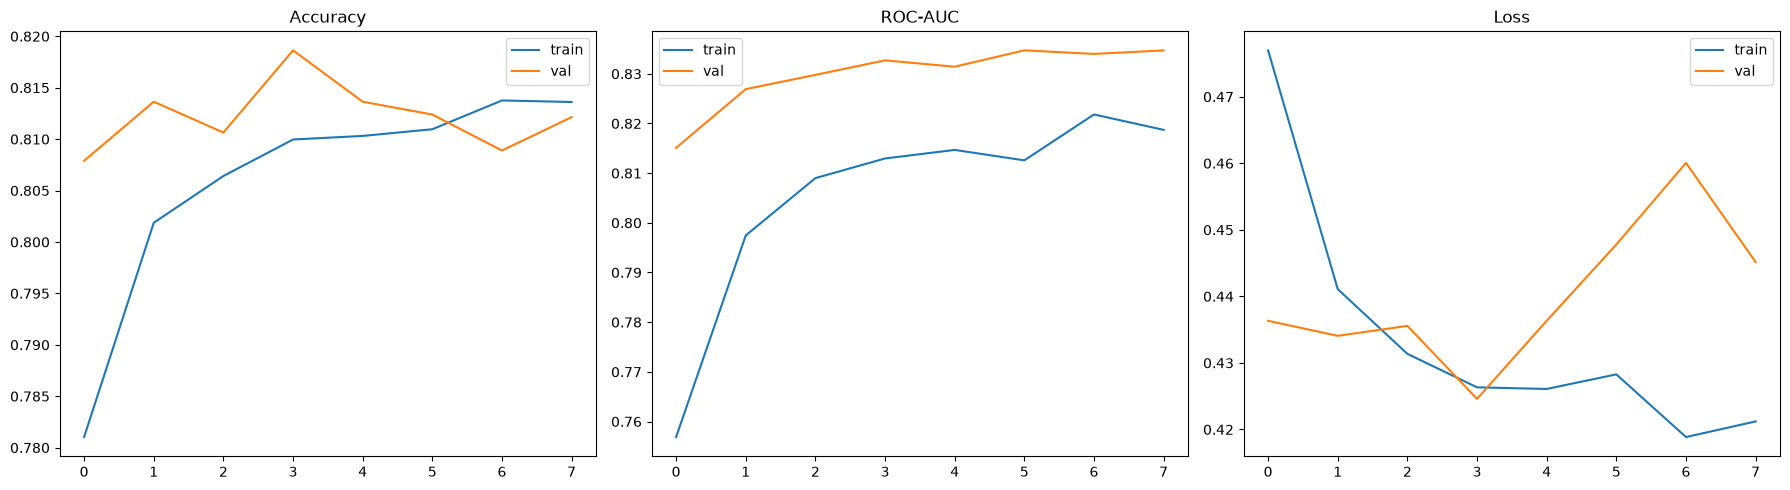

In [20]:
# ==============================
# 11.2 Courbes Stage A
# ==============================
H = pd.DataFrame(history_head.history)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(H["accuracy"], label="train")
axes[0].plot(H["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(H["auc"], label="train")
axes[1].plot(H["val_auc"], label="val")
axes[1].set_title("ROC-AUC")
axes[1].legend()

axes[2].plot(H["loss"], label="train")
axes[2].plot(H["val_loss"], label="val")
axes[2].set_title("Loss")
axes[2].legend()

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "stage_a_curves.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Stage B — Fine-tuning contrôlé

Nous dégelons seulement les dernières couches de DenseNet121. Les couches BatchNorm restent gelées : sur des datasets médicaux de taille limitée, cela évite des mises à jour statistiques trop agressives.

Le learning rate descend à `5e-6`, soit 60× moins que le début du Stage A.

In [26]:
# ============================================================
# 12.1 — Fine-tuning robuste de DenseNet121
# ============================================================
#
# IMPORTANT :
# Dans notre architecture, DenseNet121 a été créé avec :
#
#     input_tensor=x
#
# Cela signifie que Keras a intégré ses couches directement
# dans le modèle principal.
#
# Il n'existe donc PAS de couche :
#
#     model.get_layer("densenet121")
#
# Les couches DenseNet sont directement visibles dans :
#
#     model.layers
#
# Nous allons donc :
#   1. retrouver la frontière entre DenseNet et la tête finale ;
#   2. geler toutes les couches DenseNet ;
#   3. dégeler uniquement les dernières couches ;
#   4. garder BatchNormalization gelée ;
#   5. laisser la tête de classification trainable ;
#   6. recompiler avec un learning rate très faible.
# ============================================================


# ------------------------------------------------------------
# 1. Identifier la couche qui marque le début de la tête.
# ------------------------------------------------------------
# Dans notre modèle, GlobalAveragePooling2D vient juste après
# la sortie finale de DenseNet121.
# ------------------------------------------------------------

gap_index = next(
    (
        i
        for i, layer in enumerate(model.layers)
        if layer.name == "global_average_pool"
    ),
    None,
)

if gap_index is None:
    raise RuntimeError(
        "La couche 'global_average_pool' est introuvable. "
        "Vérifiez la construction du modèle."
    )


# ------------------------------------------------------------
# 2. Récupérer les couches du backbone DenseNet.
# ------------------------------------------------------------
# model.layers[0] = InputLayer "xray"
# Les couches suivantes jusqu'à global_average_pool
# correspondent au backbone DenseNet.
# ------------------------------------------------------------

backbone_layers = model.layers[1:gap_index]

print(f"Nombre de couches du backbone détectées : {len(backbone_layers)}")
print(
    "Première couche backbone :",
    backbone_layers[0].name,
)
print(
    "Dernière couche backbone :",
    backbone_layers[-1].name,
)


# ------------------------------------------------------------
# 3. Tout geler initialement.
# ------------------------------------------------------------

for layer in backbone_layers:
    layer.trainable = False


# ------------------------------------------------------------
# 4. Sélectionner uniquement les dernières couches.
# ------------------------------------------------------------
#
# Exemple :
#
# FINE_TUNE_LAYERS = 80
#
# => seules les 80 dernières couches deviennent trainables.
# ------------------------------------------------------------

n_layers_to_unfreeze = min(
    FINE_TUNE_LAYERS,
    len(backbone_layers),
)

layers_to_finetune = backbone_layers[-n_layers_to_unfreeze:]


# ------------------------------------------------------------
# 5. Dégeler les dernières couches.
# ------------------------------------------------------------
#
# BatchNormalization reste volontairement gelée.
#
# Pourquoi ?
# Les statistiques moyenne/variance apprises sur ImageNet
# peuvent être instables si on les ré-estime sur un dataset
# médical relativement différent.
# ------------------------------------------------------------

for layer in layers_to_finetune:

    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

    else:
        layer.trainable = True


# ------------------------------------------------------------
# 6. Garder la tête de classification trainable.
# ------------------------------------------------------------

for layer in model.layers[gap_index:]:
    layer.trainable = True


# ------------------------------------------------------------
# 7. Afficher le nombre de couches trainables.
# ------------------------------------------------------------

trainable_layers = [
    layer
    for layer in model.layers
    if layer.trainable
]

print()
print("==========================================")
print("FINE-TUNING CONFIGURATION")
print("==========================================")
print(
    f"Couches backbone : {len(backbone_layers)}"
)
print(
    f"Couches fine-tunées : {n_layers_to_unfreeze}"
)
print(
    f"Couches trainables totales : {len(trainable_layers)}"
)
print(
    f"Fine-tuning learning rate : {FINETUNE_LR}"
)
print(
    f"Weight decay : {WEIGHT_DECAY}"
)
print("BatchNormalization : FROZEN")
print("==========================================")


# ------------------------------------------------------------
# 8. Recompiler le modèle.
# ------------------------------------------------------------
#
# IMPORTANT :
# Après avoir modifié layer.trainable,
# Keras doit être recompilé.
# ------------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=FINETUNE_LR,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=tf.keras.losses.BinaryCrossentropy(
        label_smoothing=0.005
    ),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.5,
        ),
        tf.keras.metrics.AUC(
            name="auc",
            curve="ROC",
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR",
        ),
        tf.keras.metrics.Precision(
            name="precision",
            thresholds=0.5,
        ),
        tf.keras.metrics.Recall(
            name="recall",
            thresholds=0.5,
        ),
    ],
)


# ------------------------------------------------------------
# 9. Résumé final.
# ------------------------------------------------------------

print()
print("✅ DenseNet121 fine-tuning configuration completed.")
print(
    "✅ Les dernières couches du backbone sont maintenant "
    "trainables."
)
print(
    "✅ Les BatchNormalization restent gelées."
)
print(
    "✅ La tête de classification reste trainable."
)
print(
    "✅ Modèle recompilé avec le learning rate de fine-tuning."
)

Nombre de couches du backbone détectées : 426
Première couche backbone : zero_padding2d
Dernière couche backbone : relu

FINE-TUNING CONFIGURATION
Couches backbone : 426
Couches fine-tunées : 80
Couches trainables totales : 61
Fine-tuning learning rate : 5e-06
Weight decay : 0.0001
BatchNormalization : FROZEN

✅ DenseNet121 fine-tuning configuration completed.
✅ Les dernières couches du backbone sont maintenant trainables.
✅ Les BatchNormalization restent gelées.
✅ La tête de classification reste trainable.
✅ Modèle recompilé avec le learning rate de fine-tuning.


In [27]:
# =======================================
# 12.2 Entraînement Stage B
# =======================================

start_time = time.time()

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    class_weight=class_weight_arg,
    callbacks=make_callbacks("finetune"),
    verbose=1,
)

print(
    f"Stage B duration: {(time.time() - start_time) / 60:.1f} min"
)

Epoch 1/20
2502/2502 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8099 - auc: 0.8151 - loss: 0.4214 - pr_auc: 0.5685 - precision: 0.6169 - recall: 0.4125
Epoch 1: val_accuracy improved from None to 0.81439, saving model to /Users/mac/Downloads/clinvision-ai-final/models/best_finetune_val_accuracy.keras

Epoch 1: finished saving model to /Users/mac/Downloads/clinvision-ai-final/models/best_finetune_val_accuracy.keras

Epoch 1: val_auc improved from None to 0.83881, saving model to /Users/mac/Downloads/clinvision-ai-final/models/best_finetune_val_auc.keras

Epoch 1: finished saving model to /Users/mac/Downloads/clinvision-ai-final/models/best_finetune_val_auc.keras
2502/2502 ━━━━━━━━━━━━━━━━━━━━ 772s 305ms/step - accuracy: 0.8099 - auc: 0.8151 - loss: 0.4214 - pr_auc: 0.5685 - precision: 0.6169 - recall: 0.4125 - val_accuracy: 0.8144 - val_auc: 0.8388 - val_loss: 0.4223 - val_pr_auc: 0.5959 - val_precision: 0.6925 - val_recall: 0.3171 - learning_rate: 5.0000e-06
Epoch 2/20
2502/2502 

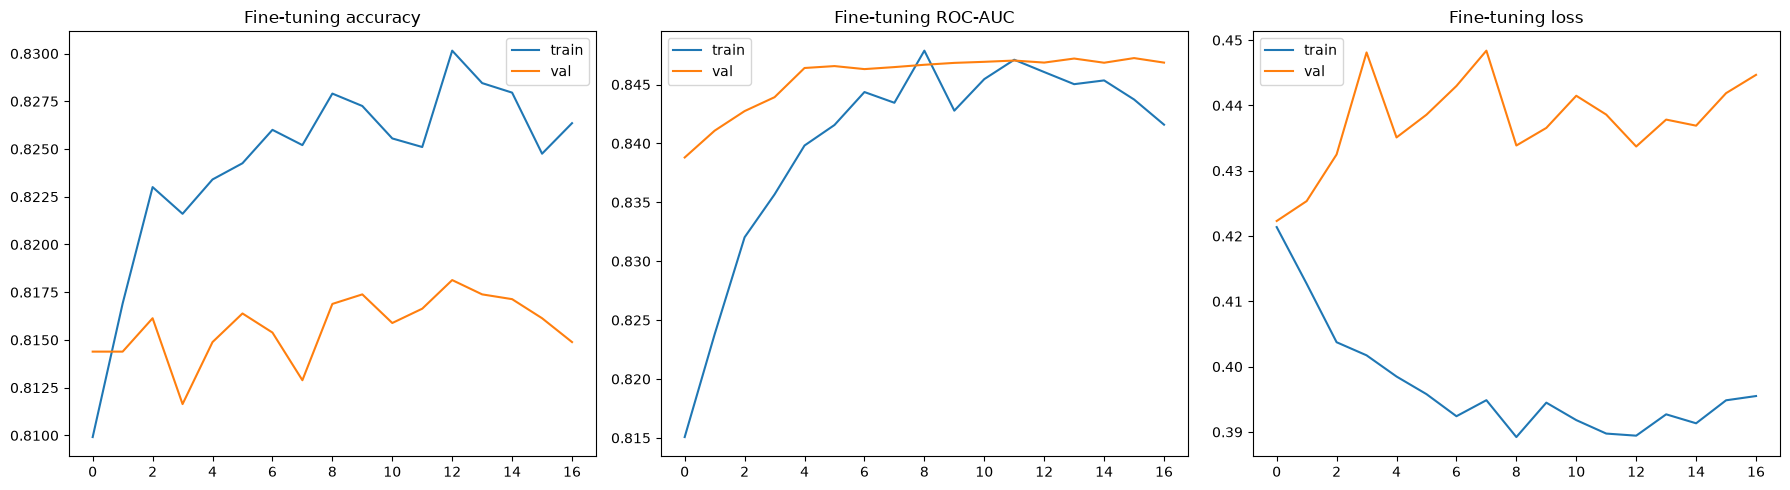

In [28]:
# ==========================================
# 12.3 Courbes Stage B et diagnostic overfit
# ==========================================
F = pd.DataFrame(history_ft.history)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(F["accuracy"], label="train")
axes[0].plot(F["val_accuracy"], label="val")
axes[0].set_title("Fine-tuning accuracy")
axes[0].legend()

axes[1].plot(F["auc"], label="train")
axes[1].plot(F["val_auc"], label="val")
axes[1].set_title("Fine-tuning ROC-AUC")
axes[1].legend()

axes[2].plot(F["loss"], label="train")
axes[2].plot(F["val_loss"], label="val")
axes[2].set_title("Fine-tuning loss")
axes[2].legend()

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "stage_b_curves.png", dpi=160, bbox_inches="tight")
plt.show()

## 13. Sélection du modèle et benchmark complet

Nous rechargeons d'abord le checkpoint ayant la meilleure `val_accuracy`, puisque c'est l'objectif prioritaire. Nous gardons également le checkpoint AUC disponible dans `models/` pour comparaison.

Ensuite, nous calculons les métriques sur **train, validation et test**. Le test reste untouched : aucune décision d'hyperparamètre ne doit utiliser ses résultats.

In [29]:
# ========================================================
# 13.1 Charger le meilleur checkpoint selon val_accuracy
# ========================================================
best_accuracy_path = MODELS_DIR / "best_finetune_val_accuracy.keras"
best_auc_path = MODELS_DIR / "best_finetune_val_auc.keras"

if best_accuracy_path.exists():
    model = tf.keras.models.load_model(best_accuracy_path, compile=False)
    print("Loaded best validation-accuracy model:", best_accuracy_path)
elif best_auc_path.exists():
    model = tf.keras.models.load_model(best_auc_path, compile=False)
    print("Fallback: loaded best validation-AUC model:", best_auc_path)
else:
    print("No checkpoint file found; using current in-memory model.")

Loaded best validation-accuracy model: /Users/mac/Downloads/clinvision-ai-final/models/best_finetune_val_accuracy.keras


In [30]:
# ============================================
# 13.2 Générer les probabilités sur chaque split
# ============================================
def predict_frame(frame: pd.DataFrame) -> np.ndarray:
    ds = make_dataset(frame, training=False)
    return model.predict(ds, verbose=1).reshape(-1)

# Les scores sont calculés indépendamment du seuil, ce qui permet ensuite
# d'évaluer ROC-AUC/PR-AUC et plusieurs seuils sans refaire l'inférence.
train_probs = predict_frame(cache_frames["train"])
val_probs = predict_frame(cache_frames["val"])
test_probs = predict_frame(cache_frames["test"])

train_y = cache_frames["train"]["label"].to_numpy()
val_y = cache_frames["val"]["label"].to_numpy()
test_y = cache_frames["test"]["label"].to_numpy()

2502/2502 ━━━━━━━━━━━━━━━━━━━━ 358s 142ms/step
501/501 ━━━━━━━━━━━━━━━━━━━━ 73s 146ms/step
334/334 ━━━━━━━━━━━━━━━━━━━━ 50s 148ms/step


In [31]:
# ==========================================================
# 13.3 Métriques binaires + spécificité
# ==========================================================
def metrics_at_threshold(y_true, probs, threshold=0.5):
    pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, probs)),
        "pr_auc": float(average_precision_score(y_true, probs)),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    }

for name, y, p in [("train", train_y, train_probs), ("validation", val_y, val_probs), ("test", test_y, test_probs)]:
    print(name, json.dumps(metrics_at_threshold(y, p, 0.5), indent=2))

train {
  "accuracy": 0.8254047571457126,
  "precision": 0.7780821917808219,
  "recall": 0.314925704147261,
  "specificity": 0.9738760239953558,
  "f1": 0.4483738553836438,
  "roc_auc": 0.8692610335744115,
  "pr_auc": 0.6723937430803348,
  "tp": 1420,
  "tn": 15098,
  "fp": 405,
  "fn": 3089
}
validation {
  "accuracy": 0.8181363977017237,
  "precision": 0.7377049180327869,
  "recall": 0.29933481152993346,
  "specificity": 0.9690422444372783,
  "f1": 0.42586750788643535,
  "roc_auc": 0.8473194756573054,
  "pr_auc": 0.6134356203684562,
  "tp": 270,
  "tn": 3005,
  "fp": 96,
  "fn": 632
}
test {
  "accuracy": 0.8242787560884226,
  "precision": 0.7578125,
  "recall": 0.3227953410981697,
  "specificity": 0.9700193423597679,
  "f1": 0.45274212368728123,
  "roc_auc": 0.863720041066308,
  "pr_auc": 0.6427024792028957,
  "tp": 194,
  "tn": 2006,
  "fp": 62,
  "fn": 407
}


## 14. Threshold optimization — correctement séparée du test

Un classifieur probabiliste ne doit pas être forcé d'utiliser `0.5` si l'objectif est une décision binaire spécifique. Mais pour éviter le leakage :

1. nous choisissons le seuil **uniquement sur validation** ;
2. nous figons ce seuil ;
3. nous l'appliquons ensuite au test.

Nous affichons également le résultat à 0.5 afin de distinguer clairement la performance intrinsèque du modèle de la performance d'une règle de décision optimisée.

Best threshold for validation accuracy: 0.31
threshold      0.310000
accuracy       0.826880
precision      0.653451
recall         0.493348
specificity    0.923896
f1             0.562224
Name: 60, dtype: float64


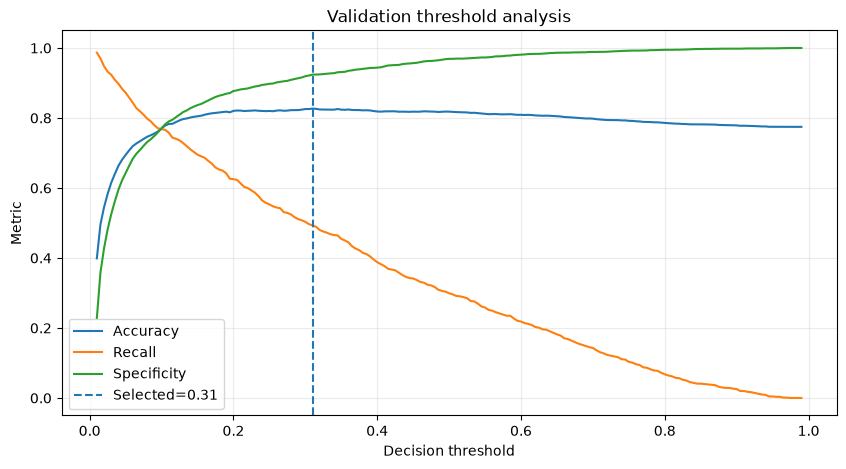

In [32]:
# ===========================================
# 14.1 Recherche du meilleur seuil de validation
# ===========================================
thresholds = np.linspace(0.01, 0.99, 197)
rows = []
for threshold in thresholds:
    m = metrics_at_threshold(val_y, val_probs, threshold)
    rows.append({"threshold": threshold, **m})
threshold_df = pd.DataFrame(rows)

best_val_row = threshold_df.loc[threshold_df["accuracy"].idxmax()]
best_threshold = float(best_val_row["threshold"])

print("Best threshold for validation accuracy:", best_threshold)
print(best_val_row[["threshold", "accuracy", "precision", "recall", "specificity", "f1"]])

plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["specificity"], label="Specificity")
plt.axvline(best_threshold, linestyle="--", label=f"Selected={best_threshold:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Metric")
plt.title("Validation threshold analysis")
plt.legend()
plt.grid(alpha=0.25)
plt.savefig(ARTIFACTS_DIR / "threshold_analysis.png", dpi=160, bbox_inches="tight")
plt.show()

In [33]:
# =====================================
# 14.2 Rapport final à seuil 0.5 + optimisé
# =====================================
benchmark = {}
for name, y, p in [("train", train_y, train_probs), ("validation", val_y, val_probs), ("test", test_y, test_probs)]:
    benchmark[name] = {
        "threshold_0_5": metrics_at_threshold(y, p, 0.5),
        "selected_validation_threshold": metrics_at_threshold(y, p, best_threshold),
    }

with open(ARTIFACTS_DIR / "final_metrics.json", "w", encoding="utf-8") as f:
    json.dump({"selected_threshold": best_threshold, "benchmark": benchmark}, f, indent=2)

print(json.dumps({"selected_threshold": best_threshold, "benchmark": benchmark}, indent=2))

{
  "selected_threshold": 0.31,
  "benchmark": {
    "train": {
      "threshold_0_5": {
        "accuracy": 0.8254047571457126,
        "precision": 0.7780821917808219,
        "recall": 0.314925704147261,
        "specificity": 0.9738760239953558,
        "f1": 0.4483738553836438,
        "roc_auc": 0.8692610335744115,
        "pr_auc": 0.6723937430803348,
        "tp": 1420,
        "tn": 15098,
        "fp": 405,
        "fn": 3089
      },
      "selected_validation_threshold": {
        "accuracy": 0.8391964821107336,
        "precision": 0.6951920169337769,
        "recall": 0.5098691505877134,
        "specificity": 0.934980326388441,
        "f1": 0.5882804503582395,
        "roc_auc": 0.8692610335744115,
        "pr_auc": 0.6723937430803348,
        "tp": 2299,
        "tn": 14495,
        "fp": 1008,
        "fn": 2210
      }
    },
    "validation": {
      "threshold_0_5": {
        "accuracy": 0.8181363977017237,
        "precision": 0.7377049180327869,
        "recall":

## 15. Confusion matrix et courbes ROC / PR

Ces graphiques sont ceux à montrer dans la présentation technique. Ils permettent de démontrer que l'on ne s'est pas arrêté à un seul chiffre d'accuracy.

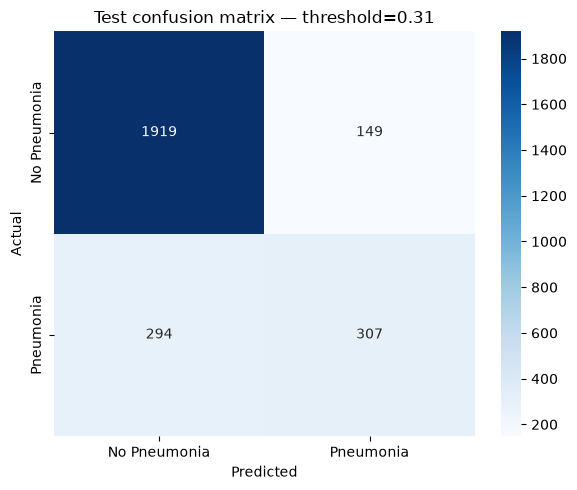

In [34]:
# ====================================
# 15.1 Confusion matrix — test
# ====================================
test_pred = (test_probs >= best_threshold).astype(int)
cm = confusion_matrix(test_y, test_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Pneumonia", "Pneumonia"], yticklabels=["No Pneumonia", "Pneumonia"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Test confusion matrix — threshold={best_threshold:.2f}")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "test_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

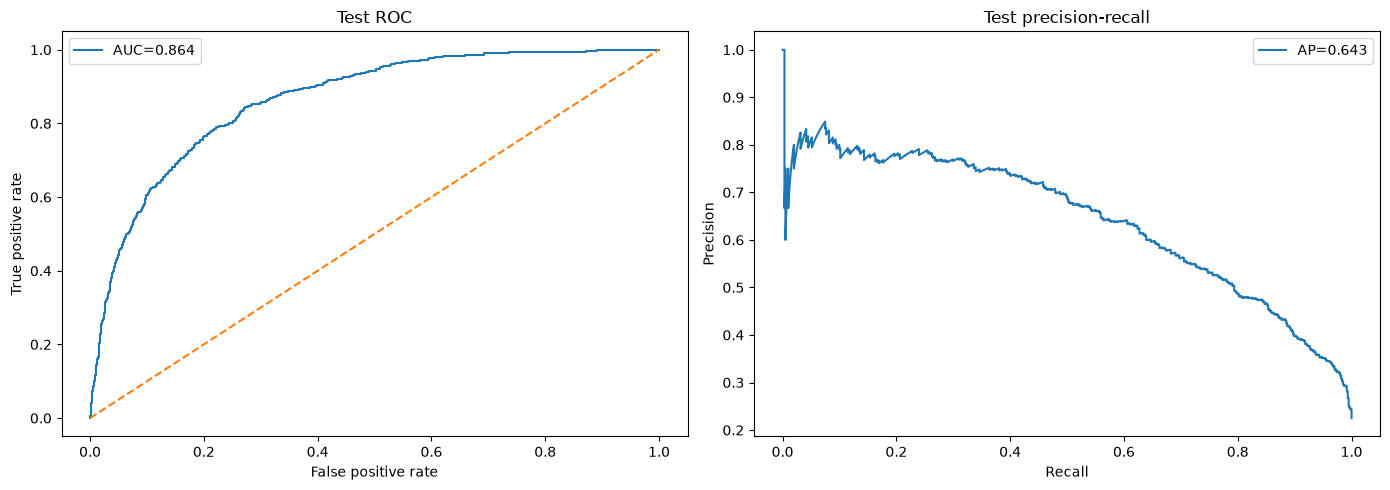

In [35]:
# ======================
# 15.2 ROC and PR curves
# ======================
fpr, tpr, _ = roc_curve(test_y, test_probs)
precision_curve, recall_curve, _ = precision_recall_curve(test_y, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(test_y, test_probs):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("Test ROC")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f"AP={average_precision_score(test_y, test_probs):.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Test precision-recall")
axes[1].legend()

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "test_roc_pr.png", dpi=160, bbox_inches="tight")
plt.show()

## 16. Accuracy > 90% : comment l'interpréter

### Trois nombres doivent être conservés séparément

**A. Training accuracy à 0.5**

Mesure la capacité du modèle sur les données d'entraînement selon le seuil standard.

**B. Validation accuracy à 0.5**

C'est le nombre directement comparable à ton ancien log `val_accuracy`.

**C. Test accuracy au seuil sélectionné sur validation**

C'est la mesure la plus honnête de la règle de décision finale, car le seuil n'a jamais été ajusté sur le test.

Si tu obtiens :

```text
Train > 90%
Validation > 90%
Test > 90%
```

avec une sensibilité/spécificité encore raisonnables, c'est un résultat intéressant.

Si tu obtiens :

```text
Accuracy = 90%
Recall = 15%
```

le modèle est surtout en train de prédire `No Pneumonia`, ce qui peut être une conséquence du déséquilibre du dataset. Le notebook est donc conçu pour rendre ce problème visible.

## 17. Grad-CAM

Grad-CAM suit :

```text
image → modèle → score cible → gradients → dernière feature map → heatmap → overlay
```

Nous ne présentons jamais le résultat comme une bounding box médicale. Pour une vraie localisation, il faut entraîner un détecteur sur les annotations RSNA.

In [36]:
# ============================================================
# 17.1 — Grad-CAM robuste
# ============================================================
#
# DenseNet121 n'est pas un sous-modèle nommé "densenet121".
# Ses couches sont directement présentes dans model.layers.
#
# Nous utilisons la dernière feature map convolutionnelle
# de DenseNet121 :
#
#     conv5_block16_concat
#
# Cette couche existe bien dans ton modèle actuel.
# ============================================================


def find_gradcam_layer(keras_model):
    """
    Recherche la dernière couche convolutionnelle DenseNet
    appropriée pour Grad-CAM.

    Priorité :
    1. conv5_block16_concat
    2. dernière couche 4-D disponible avant GAP

    Returns
    -------
    tf.keras.layers.Layer
        Couche utilisée comme feature map pour Grad-CAM.
    """

    # --------------------------------------------------------
    # 1. Recherche directe de la couche DenseNet finale.
    # --------------------------------------------------------

    preferred_layers = [
        "conv5_block16_concat",
        "conv5_block16_2_conv",
        "conv5_block16_1_relu",
    ]

    for layer_name in preferred_layers:

        try:
            layer = keras_model.get_layer(layer_name)

            # Vérification que la sortie possède bien 4 dimensions :
            #
            # batch × height × width × channels
            #
            if len(layer.output.shape) == 4:
                print(
                    f"✅ Grad-CAM layer selected: {layer.name}"
                )
                return layer

        except ValueError:
            continue


    # --------------------------------------------------------
    # 2. Fallback automatique.
    # --------------------------------------------------------
    #
    # Si jamais le nom change dans une autre version TensorFlow,
    # nous cherchons une feature map 4-D en remontant le réseau.
    # --------------------------------------------------------

    for layer in reversed(keras_model.layers):

        try:

            if len(layer.output.shape) == 4:

                print(
                    "✅ Grad-CAM fallback layer selected:",
                    layer.name,
                )

                return layer

        except Exception:
            continue


    # --------------------------------------------------------
    # 3. Aucun layer compatible trouvé.
    # --------------------------------------------------------

    raise RuntimeError(
        "Impossible de trouver une couche convolutionnelle "
        "compatible avec Grad-CAM."
    )


def prepare_cache_image(path: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Prépare une image PNG du cache pour l'inférence.

    Le modèle contient déjà DenseNet preprocess_input.
    Nous envoyons donc ici une image dans l'espace 0–255.
    """

    gray = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE,
    )

    if gray is None:
        raise ValueError(
            f"Impossible de lire l'image : {path}"
        )

    # --------------------------------------------------------
    # Redimensionnement identique au modèle.
    # --------------------------------------------------------

    gray = cv2.resize(
        gray,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA,
    )

    # --------------------------------------------------------
    # Grayscale → RGB
    #
    # DenseNet121 attend 3 canaux.
    # --------------------------------------------------------

    rgb = np.repeat(
        gray[..., None],
        3,
        axis=-1,
    ).astype(np.float32)

    # --------------------------------------------------------
    # Ajouter la dimension batch.
    # --------------------------------------------------------

    batch = np.expand_dims(
        rgb,
        axis=0,
    )

    # IMPORTANT :
    # Ne PAS appeler preprocess_input ici.
    #
    # Le modèle le fait déjà dans build_model().
    #
    # Flux :
    #
    # 0–255 image
    #      ↓
    # DenseNet preprocess_input
    #      ↓
    # DenseNet121
    # --------------------------------------------------------

    return batch, gray


def make_gradcam(
    keras_model,
    input_batch,
    gray_image,
):
    """
    Génère une visualisation Grad-CAM.

    Returns
    -------
    np.ndarray
        Image RGB avec overlay Grad-CAM.
    """

    # --------------------------------------------------------
    # Trouver la dernière feature map convolutionnelle.
    # --------------------------------------------------------

    target_layer = find_gradcam_layer(
        keras_model
    )


    # --------------------------------------------------------
    # Construire un modèle auxiliaire qui retourne :
    #
    #   1. les feature maps
    #   2. la sortie finale
    # --------------------------------------------------------

    grad_model = tf.keras.Model(
        inputs=keras_model.inputs,
        outputs=[
            target_layer.output,
            keras_model.output,
        ],
    )


    # --------------------------------------------------------
    # Calcul du gradient.
    # --------------------------------------------------------

    with tf.GradientTape() as tape:

        conv_output, score = grad_model(
            input_batch,
            training=False,
        )

        score = score[:, 0]


    # --------------------------------------------------------
    # Gradient de la probabilité Pneumonia
    # par rapport à la feature map.
    # --------------------------------------------------------

    gradients = tape.gradient(
        score,
        conv_output,
    )

    if gradients is None:
        raise RuntimeError(
            "Grad-CAM : gradients are None."
        )


    # --------------------------------------------------------
    # Global Average Pooling des gradients.
    #
    # Chaque canal reçoit un poids indiquant son importance.
    # --------------------------------------------------------

    weights = tf.reduce_mean(
        gradients,
        axis=(1, 2),
        keepdims=True,
    )


    # --------------------------------------------------------
    # Combinaison pondérée des feature maps.
    # --------------------------------------------------------

    cam = tf.reduce_sum(
        weights * conv_output,
        axis=-1,
    )[0]


    # --------------------------------------------------------
    # Garder uniquement les contributions positives.
    # --------------------------------------------------------

    cam = tf.maximum(
        cam,
        0,
    )


    # --------------------------------------------------------
    # Normalisation 0 → 1.
    # --------------------------------------------------------

    cam = cam / (
        tf.reduce_max(cam) + 1e-8
    )

    cam = cam.numpy()


    # --------------------------------------------------------
    # Redimensionner la heatmap à la taille de l'image.
    # --------------------------------------------------------

    heat = cv2.resize(
        cam,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_LINEAR,
    )


    # --------------------------------------------------------
    # Conversion en 8-bit.
    # --------------------------------------------------------

    heat = np.uint8(
        np.clip(
            heat,
            0,
            1,
        ) * 255
    )


    # --------------------------------------------------------
    # Créer la heatmap couleur.
    # --------------------------------------------------------

    heat = cv2.applyColorMap(
        heat,
        cv2.COLORMAP_JET,
    )


    # --------------------------------------------------------
    # Convertir l'image originale en BGR.
    # --------------------------------------------------------

    base = cv2.cvtColor(
        gray_image,
        cv2.COLOR_GRAY2BGR,
    )


    # --------------------------------------------------------
    # Fusion originale + heatmap.
    # --------------------------------------------------------

    overlay = cv2.addWeighted(
        base,
        0.60,
        heat,
        0.40,
        0,
    )


    # --------------------------------------------------------
    # BGR → RGB pour matplotlib.
    # --------------------------------------------------------

    return cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB,
    )

✅ Grad-CAM layer selected: conv5_block16_concat


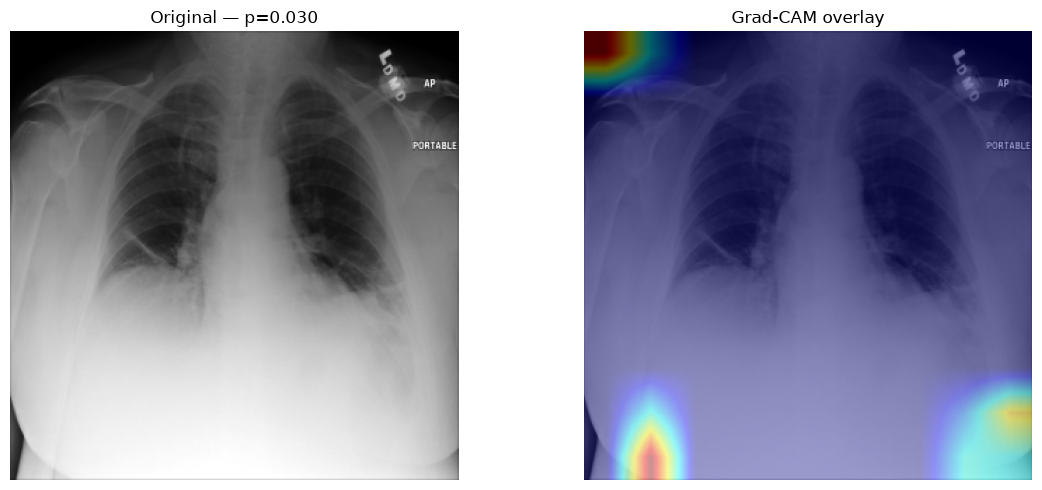

In [37]:
# ==========================================
# 17.2 Grad-CAM sur un exemple de validation
# ==========================================
example_row = cache_frames["val"].sample(1, random_state=SEED).iloc[0]
input_batch, gray = prepare_cache_image(example_row["cache_path"])
prob = float(model.predict(input_batch, verbose=0)[0][0])
overlay = make_gradcam(model, input_batch, gray)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title(f"Original — p={prob:.3f}")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title("Grad-CAM overlay")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "example_gradcam.png", dpi=160, bbox_inches="tight")
plt.show()

## 18. RSNA bounding boxes — exploration seulement

Les boxes RSNA sont des **annotations de référence** différentes de Grad-CAM. Elles sont utiles pour contrôler visuellement les cas positifs et préparer une future étape YOLO/Faster R-CNN.

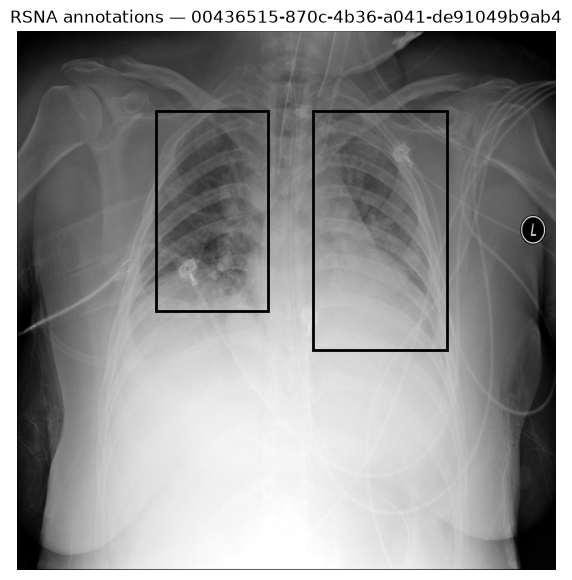

In [38]:
# ==========================================
# 18.1 Visualiser une bounding box RSNA
# ==========================================
def show_rsna_boxes(patient_id: str):
    rows = labels[labels["patientId"] == str(patient_id)]
    path = TRAIN_DICOM_DIR / f"{patient_id}.dcm"
    image = dicom_to_uint8(path)

    plt.figure(figsize=(7, 7))
    plt.imshow(image, cmap="gray")
    for _, row in rows.iterrows():
        if int(row["Target"]) == 1:
            x, y = float(row["x"]), float(row["y"])
            w, h = float(row["width"]), float(row["height"])
            rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
            plt.gca().add_patch(rect)
    plt.title(f"RSNA annotations — {patient_id}")
    plt.axis("off")
    plt.show()

positive_candidates = labels.loc[labels["Target"] == 1, "patientId"].drop_duplicates()
if len(positive_candidates):
    show_rsna_boxes(positive_candidates.iloc[0])

## 19. Sauvegarde du modèle final

Nous produisons le fichier attendu par FastAPI :

```text
models/clinvision_pneumonia.keras
```

Le preprocessing DenseNet est aussi encapsulé dans le modèle, alors que la conversion DICOM → image normalisée reste faite côté API avant entrée dans le réseau.

In [39]:
# ==========================================
# 19.1 Export du modèle de production
# ==========================================
FINAL_MODEL_PATH = MODELS_DIR / "clinvision_pneumonia.keras"
model.save(FINAL_MODEL_PATH)
print("Saved:", FINAL_MODEL_PATH)
print("Size (MB):", round(FINAL_MODEL_PATH.stat().st_size / 1024 / 1024, 2))

Saved: /Users/mac/Downloads/clinvision-ai-final/models/clinvision_pneumonia.keras
Size (MB): 28.31


## 20. Smoke test local du modèle sauvegardé

Nous rechargeons le fichier depuis disque et vérifions qu'une prédiction est identique à celle du modèle en mémoire à une petite tolérance près.

In [40]:
# ==========================================
# 20.1 Reload + inference smoke test
# ==========================================
reloaded = tf.keras.models.load_model(FINAL_MODEL_PATH, compile=False)
check_row = cache_frames["test"].iloc[0]
check_input, _ = prepare_cache_image(check_row["cache_path"])
p1 = float(model.predict(check_input, verbose=0)[0][0])
p2 = float(reloaded.predict(check_input, verbose=0)[0][0])
print("Original probability:", p1)
print("Reloaded probability:", p2)
print("Absolute difference:", abs(p1 - p2))
assert abs(p1 - p2) < 1e-5
print("✅ Saved-model smoke test passed.")

Original probability: 0.035270851105451584
Reloaded probability: 0.035270851105451584
Absolute difference: 0.0
✅ Saved-model smoke test passed.


## 21. Résumé final du benchmark

Cette cellule construit un tableau simple à copier dans le rapport / pitch. **Elle imprime les vraies métriques de ton run ; aucune valeur n'est hard-codée.**

In [41]:
# ===========================================
# 21.1 Tableau final
# ===========================================
summary_rows = []
for name, y, p in [("Train", train_y, train_probs), ("Validation", val_y, val_probs), ("Test", test_y, test_probs)]:
    m05 = metrics_at_threshold(y, p, 0.5)
    ms = metrics_at_threshold(y, p, best_threshold)
    summary_rows.append({
        "Split": name,
        "Accuracy@0.5": m05["accuracy"],
        "Accuracy@selected": ms["accuracy"],
        "ROC-AUC": m05["roc_auc"],
        "PR-AUC": m05["pr_auc"],
        "Precision@selected": ms["precision"],
        "Recall@selected": ms["recall"],
        "Specificity@selected": ms["specificity"],
        "F1@selected": ms["f1"],
    })

benchmark_df = pd.DataFrame(summary_rows)
display(benchmark_df.style.format({c: "{:.4f}" for c in benchmark_df.columns if c != "Split"}))
benchmark_df.to_csv(ARTIFACTS_DIR / "benchmark_summary.csv", index=False)

,Split,Accuracy@0.5,Accuracy@selected,ROC-AUC,PR-AUC,Precision@selected,Recall@selected,Specificity@selected,F1@selected
0,Train,0.8254,0.8392,0.8693,0.6724,0.6952,0.5099,0.9350,0.5883
1,Validation,0.8181,0.8269,0.8473,0.6134,0.6535,0.4933,0.9239,0.5622
2,Test,0.8243,0.8340,0.8637,0.6427,0.6732,0.5108,0.9279,0.5809


# 22. Lancer FastAPI et Streamlit

Le notebook a terminé le travail ML. Les deux applications sont séparées volontairement.

### Terminal 1 — FastAPI

```bash
uvicorn backend.main:app --host 0.0.0.0 --port 8000
```

### Terminal 2 — Streamlit

```bash
streamlit run frontend/app.py
```

Puis ouvrir :

```text
http://localhost:8501
```

### Vérification API

```bash
curl http://localhost:8000/health
```

Les endpoints complets sont documentés dans `/docs`.

# 23. Checklist finale avant le hackathon

- [ ] Competition RSNA rejointe/règles acceptées sur Kaggle.
- [ ] Dataset RSNA téléchargé automatiquement par le notebook.
- [ ] Dataset extrait et vérifié (`stage_2_train_labels.csv` + DICOM).
- [ ] Split patient-level vérifié.
- [ ] `preprocess_errors.csv` inspecté.
- [ ] Meilleur checkpoint choisi sur validation.
- [ ] Test exécuté une seule fois après sélection.
- [ ] `models/clinvision_pneumonia.keras` généré.
- [ ] `artifacts/example_gradcam.png` généré.
- [ ] FastAPI `/health` retourne `ok`.
- [ ] Streamlit analyse une image.
- [ ] Démo 90 secondes testée hors ligne avec quelques images connues.
- [ ] Aucun DICOM, secret ou API key commité dans Git.